# CuRIOS FITS Imaging - Version 2.9

This notebook demonstrates the standard workflow for analyzing a CuRIOS FITS image.

Workflow:

1. Configure analysis parameters
2. Select an observing folder and image
3. Analyze the image
4. Display the standard report
5. (Optional) Run additional diagnostics

For advanced examples, see the notebooks in the `examples/` directory.

In [1]:
import os
from pathlib import Path

from fits_imaging.config import ImagingConfig
from fits_imaging.analysis import analyze_image
from fits_imaging.session import ImagingSession

In [3]:
data_root_text = os.environ.get(
    "CURIOS_DATA_ROOT",
    "~/Library/CloudStorage/Dropbox/CuRIOS/Software/DataDirectories",
)

data_root = Path(data_root_text).expanduser().resolve()

if not data_root.exists():
    raise FileNotFoundError(
        f"Data directory does not exist: {data_root}. "
        "Set the CURIOS_DATA_ROOT environment variable or edit data_root."
    )

config = ImagingConfig(data_root=data_root)

config.colormap = "viridis"
config.contrast_method = "sigma"
config.contrast_sigma_low = 1.0
config.contrast_sigma_high = 5.0
config.stretch = "linear"

session = ImagingSession(data_root=data_root)

print("Data root:", session.data_root)
print("State file:", session.state_path)
print("Configuration updated")

Data root: /Users/svwbeckwith/Library/CloudStorage/Dropbox/CuRIOS/Software/DataDirectories
State file: /Users/svwbeckwith/.config/curios-fits-imaging/session.json
Configuration updated


In [5]:
session.folder_table()

,index,folder,path
0,0,Archive,/Users/svwbeckwith/Library/CloudStorage/Dropbo...
1,1,CowTests,/Users/svwbeckwith/Library/CloudStorage/Dropbo...
2,2,Images,/Users/svwbeckwith/Library/CloudStorage/Dropbo...
3,3,Lib-0610,/Users/svwbeckwith/Library/CloudStorage/Dropbo...
4,4,Patio-0629,/Users/svwbeckwith/Library/CloudStorage/Dropbo...
5,5,Patio-0703,/Users/svwbeckwith/Library/CloudStorage/Dropbo...
6,6,Patio-0720,/Users/svwbeckwith/Library/CloudStorage/Dropbo...
7,7,Patio-0725,/Users/svwbeckwith/Library/CloudStorage/Dropbo...
8,8,Patio-0726,/Users/svwbeckwith/Library/CloudStorage/Dropbo...


In [7]:
folder_index = 8
selected_folder = session.set_folder_by_index(folder_index)

print("Selected folder:", selected_folder)


Selected folder: /Users/svwbeckwith/Library/CloudStorage/Dropbox/CuRIOS/Software/DataDirectories/Patio-0726


In [9]:
run = session.open_run()

print("FITS files:", len(run.files))
print("Image types:", run.kinds())
run.preview(kind="science", n=25)


FITS files: 9
Image types: ['science_single', 'science_sum']


,index,file,kind,include
0,0,Alkaid_2026-07-27_04.00.51_CuED-0.fits,science_single,True
1,1,Altair_2026-07-27_04.11.14_CuED_5_sum.fits,science_sum,True
2,2,Antares_2026-07-27_04.05.13_CuED_5_sum.fits,science_sum,True
3,3,Arcturus_2026-07-27_04.02.03_CuED_5_sum.fits,science_sum,True
4,4,Deneb_2026-07-27_04.13.59_CuED_5_sum.fits,science_sum,True
5,5,Dubhe_2026-07-27_03.56.42_CuED-0.fits,science_single,True
6,6,Polaris_2026-07-27_03.52.41_CuED_5_sum.fits,science_sum,True
7,7,Spica_2026-07-27_03.58.00_CuED_5_sum.fits,science_sum,True
8,8,Vega_2026-07-27_04.08.06_CuED_5_sum.fits,science_sum,True


In [11]:
image_index = 4
image_path = session.set_image_by_index(image_index, kind="science")
results = analyze_image(image_path, config)

print("Selected image:", image_path)
print("Analysis complete")

Selected image: /Users/svwbeckwith/Library/CloudStorage/Dropbox/CuRIOS/Software/DataDirectories/Patio-0726/Deneb_2026-07-27_04.13.59_CuED_5_sum.fits
Analysis complete


Deneb  9576 x 6380  Apx60-CuED  0.025 sec
Analysis mode: source_detection
RAH:  20.691  Dec:  45.280  PA: 284.81  PA2:  75.19  Alt:    42.5  Az:    59.4
Mean: 493.6  Median: 494.0  Std: 11.6  Min: 99.0  Max: 9570.0
Found 30 peaks in 2.92 sec

Source statistics:
{'nstars': 30, 'median_fwhm': 1.5717251300811768, 'median_flux': 286.5, 'brightest_flux': 300033.0}

Selected-region source statistics:
{'nstars': 10, 'median_fwhm': 1.5778746604919434, 'median_flux': 262.0, 'brightest_flux': 300033.0}


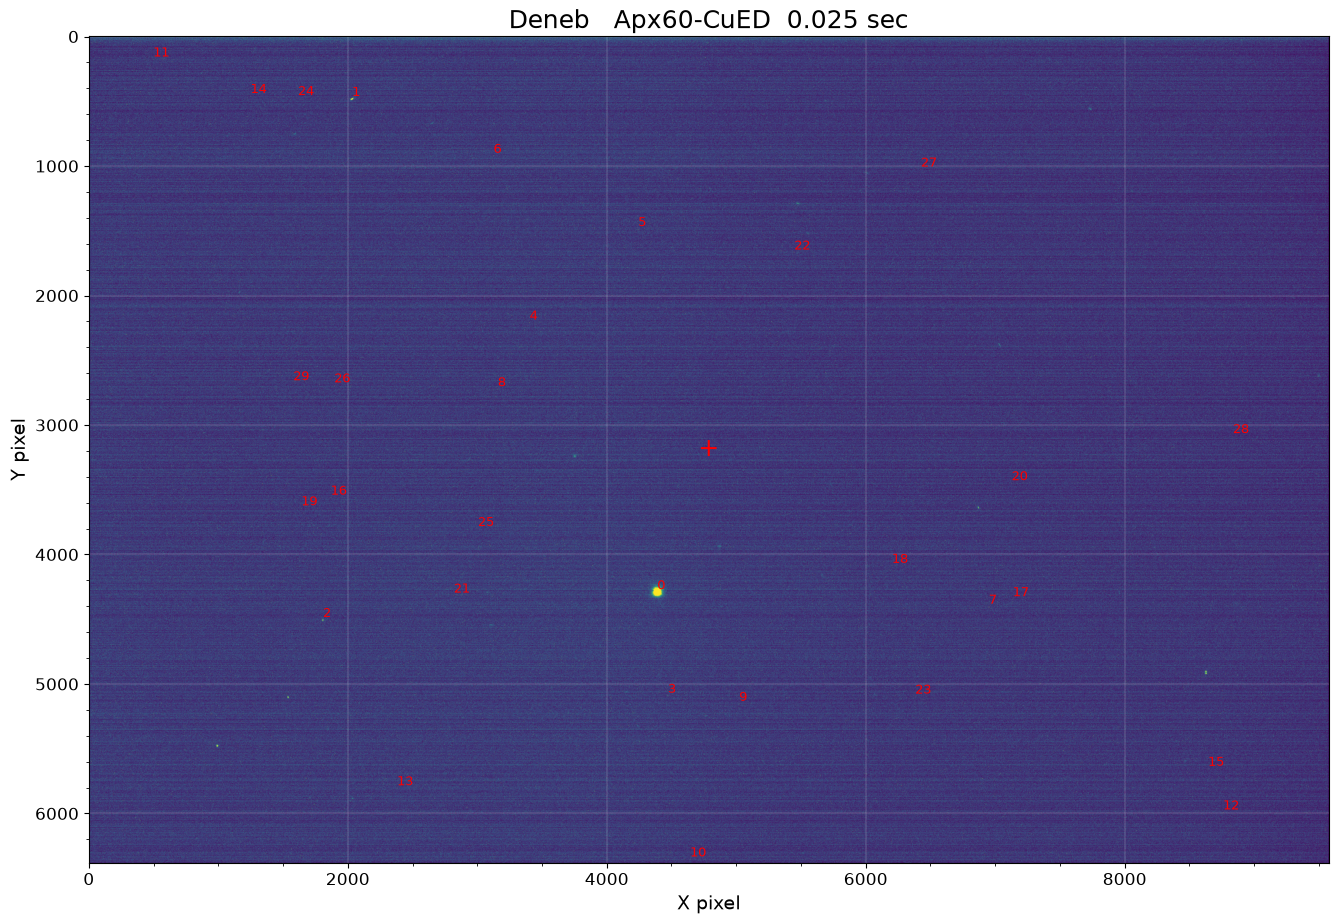


Peak#        X        Y        Area       sx      sy        Flux      Mag
------------------------------------------------------------------------------
    0   4389.88   4291.56    380932.9    3.05    3.25    300033.0    2.454
    1   2033.68    482.05      9179.7    5.23    3.97      4145.0    7.103
    2   1808.37   4505.59      5063.7    1.83    4.60      2593.0    7.612
    3   4472.58   5091.22       294.1    0.78    0.72       605.0    9.192
    4   3404.52   2209.36      4668.6    0.24    1.77       533.0    9.330
    5   4242.95   1487.48       261.8    0.59    0.70       494.0    9.412
    6   3125.73    921.51       288.6    0.56    0.66       484.0    9.434
    7   6950.33   4403.25       302.6    0.74    0.47       469.0    9.469
    8   3158.94   2723.57       473.2    0.64    1.21       468.0    9.471
    9   5022.94   5153.59       286.1    0.66    0.75       411.0    9.612
   10   4643.69   6355.16       308.4    0.48    0.86       411.0    9.612
   11    497.85    17

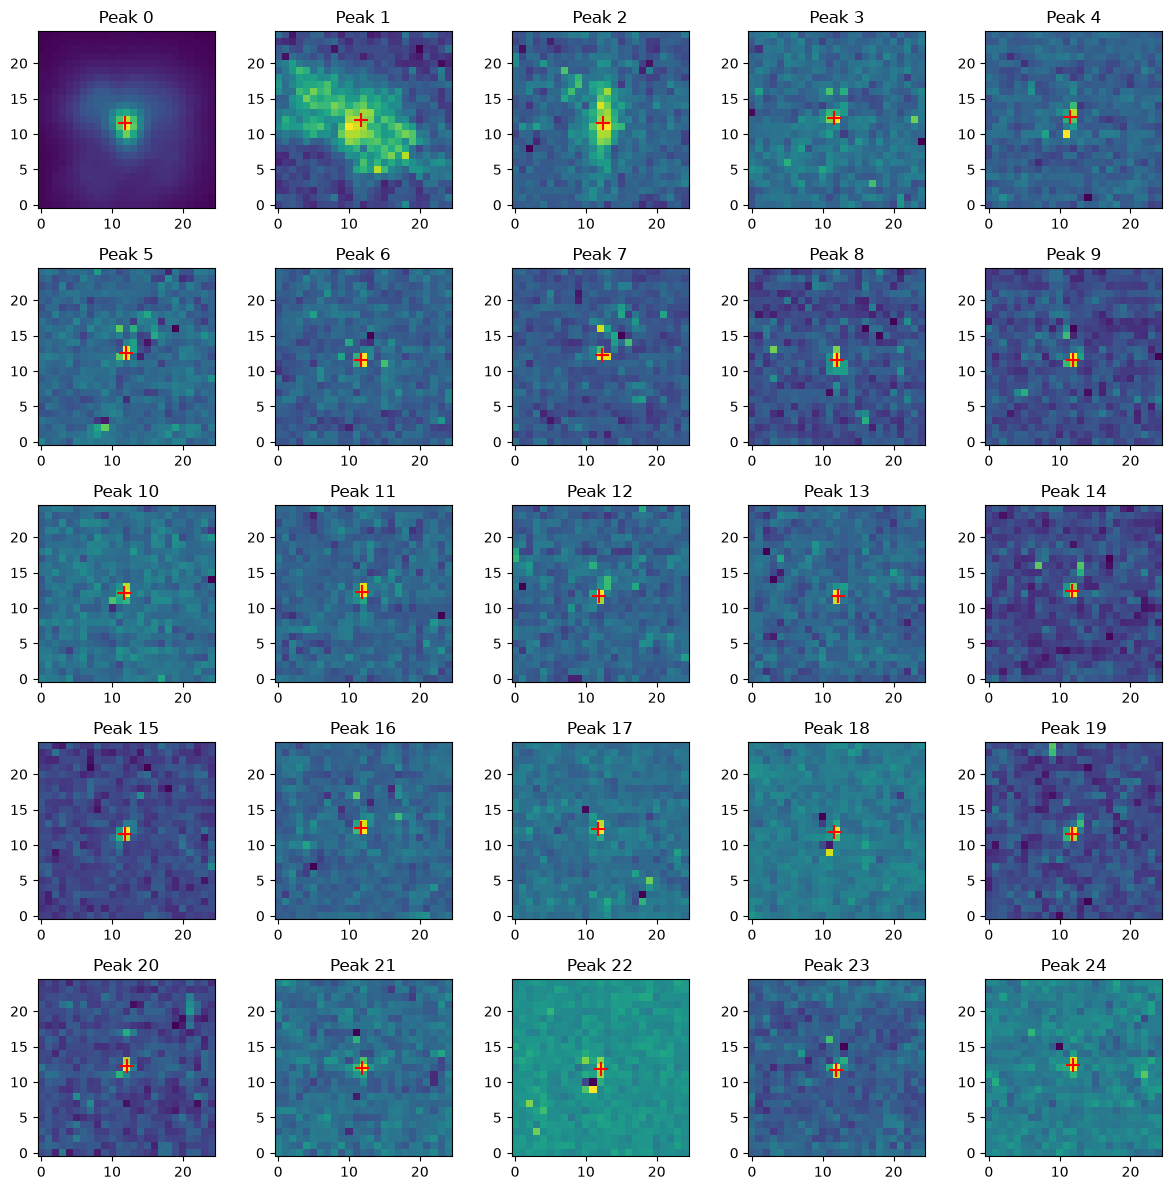

In [13]:
results.report(
    config=config,
    show_summary=True,
    show_image=True,
    show_table=True,
    show_cutouts=True,
    show_histogram=False,
    show_statistics=True,
)

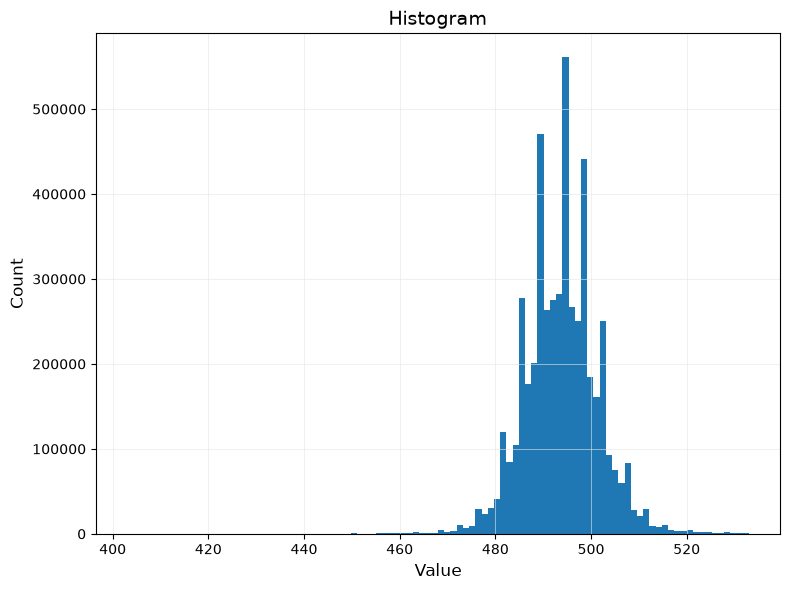

In [15]:
import matplotlib.pyplot as plt
results.plot_histogram(config=config)
plt.show()

In [17]:
results.source_statistics()

{'nstars': 30,
 'median_fwhm': 1.5717251300811768,
 'median_flux': 286.5,
 'brightest_flux': 300033.0}

In [19]:
batch_results, batch_summary = session.analyze_current_folder(
    config,
    kind="science",
    max_files=10,
)

batch_summary

[1/9] Alkaid_2026-07-27_04.00.51_CuED-0.fits
[2/9] Altair_2026-07-27_04.11.14_CuED_5_sum.fits
[3/9] Antares_2026-07-27_04.05.13_CuED_5_sum.fits
[4/9] Arcturus_2026-07-27_04.02.03_CuED_5_sum.fits
[5/9] Deneb_2026-07-27_04.13.59_CuED_5_sum.fits
[6/9] Dubhe_2026-07-27_03.56.42_CuED-0.fits
[7/9] Polaris_2026-07-27_03.52.41_CuED_5_sum.fits
[8/9] Spica_2026-07-27_03.58.00_CuED_5_sum.fits
[9/9] Vega_2026-07-27_04.08.06_CuED_5_sum.fits


,file,path,kind,analysis_mode,object,camera,exposure_sec,nstars,median_fwhm_pixels,median_background,background_sigma,brightest_flux,peak_find_time_sec,stats_region,focus_sharpness,gradient_anisotropy,gradient_angle_deg
0,Alkaid_2026-07-27_04.00.51_CuED-0.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_single,source_detection,Alkaid,Apx60-CuED,0.010,2,7.343746,108.0,5.866696,45431.0,3.855501,center_fraction,None,None,None
1,Altair_2026-07-27_04.11.14_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Altair,Apx60-CuED,0.015,2,3.950277,494.0,17.276219,240230.0,3.872143,center_fraction,None,None,None
2,Antares_2026-07-27_04.05.13_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Antares,Apx60-CuED,0.020,5,8.870814,503.0,20.413080,170222.0,3.890766,center_fraction,None,None,None
3,Arcturus_2026-07-27_04.02.03_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Arcturus,Apx60-CuED,0.005,8,1.682539,494.0,16.866729,184624.0,3.788240,center_fraction,None,None,None
4,Deneb_2026-07-27_04.13.59_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Deneb,Apx60-CuED,0.025,30,1.571725,494.0,11.645672,300033.0,3.742293,center_fraction,None,None,None
5,Dubhe_2026-07-27_03.56.42_CuED-0.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_single,source_detection,Dubhe,Apx60-CuED,0.009,1,10.622739,140.0,9.749600,36481.0,3.838363,center_fraction,None,None,None
6,Polaris_2026-07-27_03.52.41_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Polaris,Apx60-CuED,0.060,1,11.397878,862.0,47.913969,216455.0,3.810182,center_fraction,None,None,None
7,Spica_2026-07-27_03.58.00_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Spica,Apx60-CuED,0.020,3,9.528467,538.0,22.084392,321807.0,3.970535,center_fraction,None,None,None
8,Vega_2026-07-27_04.08.06_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Vega,Apx60-CuED,0.005,19,1.434802,492.0,11.982880,199344.0,3.919251,center_fraction,None,None,None


In [21]:
batch_summary.to_csv("batch_summary.csv", index=False)

In [23]:
run = session.open_run()

len(run.files), run.folder, run.kinds()

(9,
 PosixPath('/Users/svwbeckwith/Library/CloudStorage/Dropbox/CuRIOS/Software/DataDirectories/Patio-0726'),
 ['science_single', 'science_sum'])

In [25]:
run.file_table[["file", "kind", "include"]]

,file,kind,include
0,Alkaid_2026-07-27_04.00.51_CuED-0.fits,science_single,True
1,Altair_2026-07-27_04.11.14_CuED_5_sum.fits,science_sum,True
2,Antares_2026-07-27_04.05.13_CuED_5_sum.fits,science_sum,True
3,Arcturus_2026-07-27_04.02.03_CuED_5_sum.fits,science_sum,True
4,Deneb_2026-07-27_04.13.59_CuED_5_sum.fits,science_sum,True
5,Dubhe_2026-07-27_03.56.42_CuED-0.fits,science_single,True
6,Polaris_2026-07-27_03.52.41_CuED_5_sum.fits,science_sum,True
7,Spica_2026-07-27_03.58.00_CuED_5_sum.fits,science_sum,True
8,Vega_2026-07-27_04.08.06_CuED_5_sum.fits,science_sum,True


In [27]:
summary = run.analyze_all(config, kind="science", max_files=5)
summary

[1/5] Alkaid_2026-07-27_04.00.51_CuED-0.fits
[2/5] Altair_2026-07-27_04.11.14_CuED_5_sum.fits
[3/5] Antares_2026-07-27_04.05.13_CuED_5_sum.fits
[4/5] Arcturus_2026-07-27_04.02.03_CuED_5_sum.fits
[5/5] Deneb_2026-07-27_04.13.59_CuED_5_sum.fits


,file,path,kind,analysis_mode,object,camera,exposure_sec,nstars,median_fwhm_pixels,median_background,background_sigma,brightest_flux,peak_find_time_sec,stats_region,focus_sharpness,gradient_anisotropy,gradient_angle_deg
0,Alkaid_2026-07-27_04.00.51_CuED-0.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_single,source_detection,Alkaid,Apx60-CuED,0.010,2,7.343746,108.0,5.866696,45431.0,3.780289,center_fraction,None,None,None
1,Altair_2026-07-27_04.11.14_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Altair,Apx60-CuED,0.015,2,3.950277,494.0,17.276219,240230.0,3.730580,center_fraction,None,None,None
2,Antares_2026-07-27_04.05.13_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Antares,Apx60-CuED,0.020,5,8.870814,503.0,20.413080,170222.0,3.811934,center_fraction,None,None,None
3,Arcturus_2026-07-27_04.02.03_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Arcturus,Apx60-CuED,0.005,8,1.682539,494.0,16.866729,184624.0,3.754827,center_fraction,None,None,None
4,Deneb_2026-07-27_04.13.59_CuED_5_sum.fits,/Users/svwbeckwith/Library/CloudStorage/Dropbo...,science_sum,source_detection,Deneb,Apx60-CuED,0.025,30,1.571725,494.0,11.645672,300033.0,3.800769,center_fraction,None,None,None


In [ ]:
# Explicit analysis modes can be used when needed:
#   mode="source_detection"
#   mode="statistics"
#   mode="focus"
#   mode="rotation_blur"
#
# If mode is omitted, ImagingRun chooses a default from each file's kind.
# For example, darks and flats use statistics, while science images use source detection.